<a href="https://colab.research.google.com/github/XavierMojica/Portfolio/blob/main/2Way_ANOVA_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#Libraries
import pandas as pd
import numpy as np
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf

#!pip install pingouin
import pingouin as pg

In [2]:
#read in csv file
from google.colab import files
import pandas as pd

uploaded = files.upload()

data = pd.read_csv("ab_data.csv")
data.head()

Saving ab_data.csv to ab_data.csv


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [4]:
#random seed
np.random.seed(285)

data['country'] = np.random.choice(
    ['US', 'AU', 'UK'], size = len(data), replace = True, p = [0.55, 0.25, 0.20]
)

In [5]:
#reults
print(data.head())

#country counts
print(data['country'].value_counts())


   user_id                   timestamp      group landing_page  converted  \
0   851104  2017-01-21 22:11:48.556739    control     old_page          0   
1   804228  2017-01-12 08:01:45.159739    control     old_page          0   
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0   
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0   
4   864975  2017-01-21 01:52:26.210827    control     old_page          1   

  country  
0      US  
1      US  
2      AU  
3      AU  
4      AU  
country
US    161298
AU     73969
UK     59211
Name: count, dtype: int64


In [7]:
#check to see what dtype is per column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
 5   country       294478 non-null  object
dtypes: int64(2), object(4)
memory usage: 13.5+ MB


In [10]:
#convert timestamp into time format from object
data['timestamp'] = pd.to_datetime(data['timestamp'], errors= 'coerce')

#convert converted colum to int8
data['converted'] = data['converted'].astype('int8')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int8          
 5   country       294478 non-null  object        
dtypes: datetime64[ns](1), int64(1), int8(1), object(3)
memory usage: 11.5+ MB


In [14]:
#seeing what the highest userid is
data[data["user_id"] == data["user_id"].max()]

,user_id,timestamp,group,landing_page,converted,country
237031,945999,2017-01-16 04:56:21.132067,treatment,new_page,0,US


In [16]:
#change user id column to int 32 instead of int64
data['user_id'] = data['user_id'].astype('int32')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int32         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int8          
 5   country       294478 non-null  object        
dtypes: datetime64[ns](1), int32(1), int8(1), object(3)
memory usage: 10.4+ MB


In [19]:
#see if any nas
data.isna().sum()


,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0
country,0


In [20]:

#checking country counts
data.country.value_counts()

,count
country,
US,161298
AU,73969
UK,59211


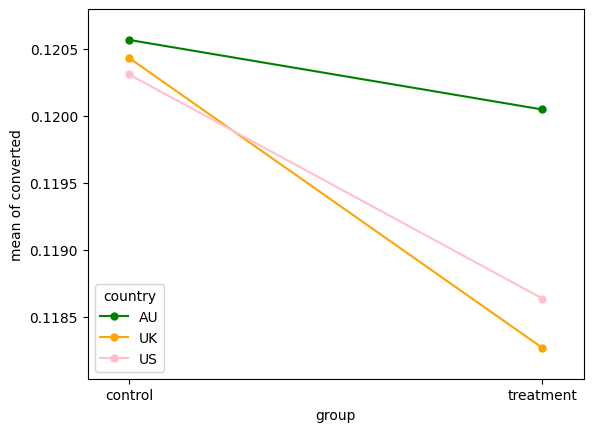

In [25]:
#looking at the interactions between variables

figure = interaction_plot(x =data.group, trace = data.country, response = data.converted,
                          colors = ['green', 'orange', 'pink'], ms =10)

In [32]:
#Doing the ANOVA

aov = pg.anova(dv= 'converted', between = ['group','country'], data = data, detailed = True)
aov

,Source,SS,DF,MS,F,p_unc,np2
0,group,0.161472,1.0,0.161472,1.532834,0.215689,5.205336e-06
1,country,0.042419,2.0,0.021209,0.201337,0.817637,1.367441e-06
2,group * country,0.025469,2.0,0.012735,0.120889,0.886133,8.210541e-07
3,Residual,31020.339940,294472.0,0.105342,NaN,NaN,NaN


Doing a Logistic Regression Instead since we have a binary Response for 0 and 1 as Converted

In [51]:
import statsmodels.formula.api as smf

model = smf.logit(
    "converted ~ group * country",
    data=data
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.366242
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               294478
Model:                          Logit   Df Residuals:                   294472
Method:                           MLE   Df Model:                            5
Date:                Thu, 28 May 2026   Pseudo R-squ.:               1.009e-05
Time:                        03:51:47   Log-Likelihood:            -1.0785e+05
converged:                       True   LL-Null:                   -1.0785e+05
Covariance Type:            nonrobust   LLR p-value:                    0.8242
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.9871      0.016   -124.22

In [52]:
odds_ratios = np.exp(model.params)

results_table = pd.DataFrame({
    "coef_log_odds": model.params,
    "odds_ratio": np.exp(model.params),
    "p_value": model.pvalues
})

results_table

,coef_log_odds,odds_ratio,p_value
Intercept,-1.987066,0.137097,0.000000
group[T.treatment],-0.004905,0.995107,0.828231
country[T.UK],-0.001268,0.998733,0.957794
country[T.US],-0.002433,0.997570,0.899728
group[T.treatment]:country[T.UK],-0.015679,0.984443,0.644372
group[T.treatment]:country[T.US],-0.010986,0.989075,0.687669
